<a href="https://colab.research.google.com/github/AdityaJare/ML-PRojects/blob/main/california_housing_ann.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [121]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow
from tensorflow import keras

In [122]:
data = fetch_california_housing(as_frame=True)

In [123]:
df = data.frame

In [124]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [125]:
df.shape

(20640, 9)

In [126]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


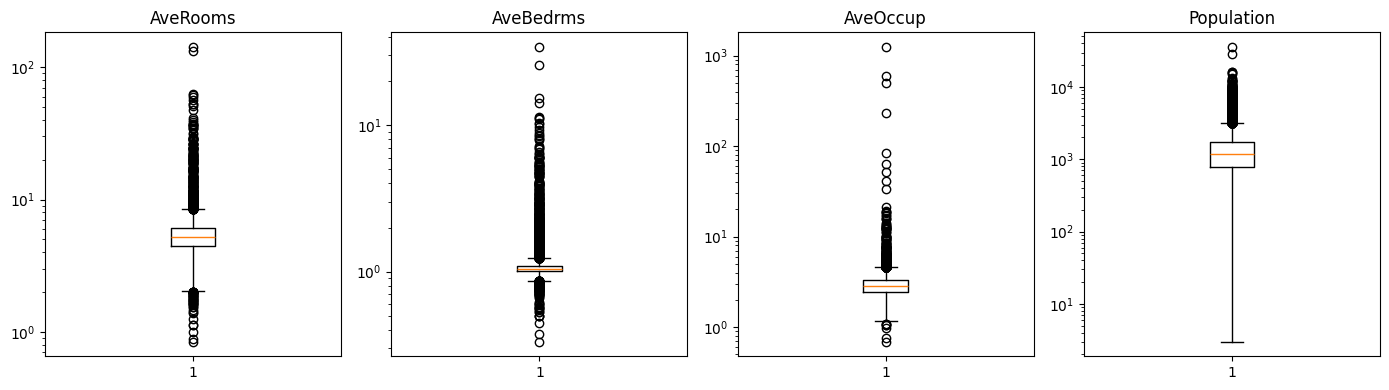

In [127]:
cols = ["AveRooms", "AveBedrms", "AveOccup", "Population"]

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, col in zip(axes, cols):
    ax.boxplot(df[col])
    ax.set_title(col)
    ax.set_yscale("log")
plt.tight_layout()
plt.show()

In [128]:
df[cols].describe(percentiles=[.01, .5, .99])

,AveRooms,AveBedrms,AveOccup,Population
count,20640.000000,20640.000000,20640.000000,20640.000000
mean,5.429000,1.096675,3.070655,1425.476744
std,2.474173,0.473911,10.386050,1132.462122
min,0.846154,0.333333,0.692308,3.000000
1%,2.581133,0.872840,1.536686,88.000000
50%,5.229129,1.048780,2.818116,1166.000000
99%,10.357033,2.127541,5.394812,5805.830000
max,141.909091,34.066667,1243.333333,35682.000000


In [129]:
X=df.iloc[:, :-1]
Y = df.iloc[:, -1]

In [130]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [131]:
mask = (
    (x_train["AveRooms"] < 20) &
    (x_train["AveBedrms"] < 5) &
    (x_train["AveOccup"] < 10) &
    (x_train["Population"] < 15000)
)

print("rows removed:", (~mask).sum(), "of", len(x_train))

x_train_clean = x_train[mask]
y_train_clean = y_train[mask]

rows removed: 99 of 16512


In [132]:
scaler = StandardScaler()
x_train_s = scaler.fit_transform(x_train_clean)
x_test_s = scaler.transform(x_test)

In [133]:
n_features = x_train.shape[1]

In [134]:
n_features

8

In [135]:
model= keras.Sequential()

model.add(keras.layers.Input(shape=(n_features,)))

model.add(keras.layers.Dense(128, activation="relu"))

model.add(keras.layers.Dropout(0.2))

model.add(keras.layers.Dense(64, activation="relu"))

model.add(keras.layers.Dropout(0.2))


model.add(keras.layers.Dense(1))

In [136]:
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,473 (37.00 KB)

 Trainable params: 9,473 (37.00 KB)

 Non-trainable params: 0 (0.00 B)

In [137]:
initial_weights = model.get_weights()

initial_weights[0] = np.random.randn(8, 128) * np.sqrt(1/8)
initial_weights[1] = np.zeros(model.get_weights()[1].shape[0])
initial_weights[2] = np.random.randn(128, 64) * np.sqrt(1/ 128)
initial_weights[3] = np.zeros(model.get_weights()[3].shape[0])
initial_weights[4] = np.random.randn(64, 1) * np.sqrt(1 / 64)
initial_weights[5] = np.zeros(model.get_weights()[5].shape[0])

model.set_weights(initial_weights)

In [138]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

In [139]:
early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, mode="auto", restore_best_weights=True)

In [140]:
history = model.fit(
    x_train_s, y_train_clean,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    validation_split=0.2,
    verbose=1
)

Epoch 1/200
411/411 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.8937 - mae: 0.6781 - val_loss: 0.4625 - val_mae: 0.4868
Epoch 2/200
411/411 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5141 - mae: 0.5193 - val_loss: 0.4031 - val_mae: 0.4550
Epoch 3/200
411/411 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4563 - mae: 0.4886 - val_loss: 0.4095 - val_mae: 0.4441
Epoch 4/200
411/411 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4277 - mae: 0.4678 - val_loss: 0.3774 - val_mae: 0.4318
Epoch 5/200
411/411 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.4100 - mae: 0.4592 - val_loss: 0.3754 - val_mae: 0.4269
Epoch 6/200
411/411 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3953 - mae: 0.4491 - val_loss: 0.3632 - val_mae: 0.4165
Epoch 7/200
411/411 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3883 - mae: 0.4430 - val_loss: 0.3527 - val_mae: 0.4117
Epoch 8/200
411/411 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3811 - mae: 0.4389 - val_loss: 0.3460 - val_mae: 0.4140
Epoch 9/200
411/411 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/

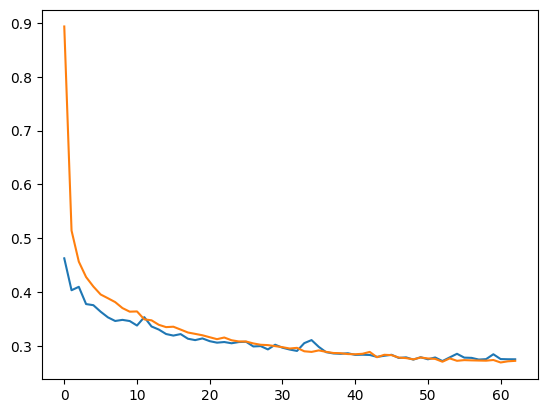

In [143]:
plt.plot(history.history["val_loss"])
plt.plot(history.history["loss"])

In [144]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
lo, hi = x_train_clean.min(), x_train_clean.max()
x_test_s = scaler.transform(x_test.clip(lower=lo, upper=hi, axis=1))

pred = model.predict(x_test_s).ravel()
print("ANN  RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("ANN  MAE: ", mean_absolute_error(y_test, pred))
print("ANN  R²:  ", r2_score(y_test, pred))
print("pred range:", pred.min(), pred.max())


129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
ANN  RMSE: 0.5164471030512606
ANN  MAE:  0.3505201725645306
ANN  R²:   0.7964623146827927
pred range: 0.3902099 5.8032017
